# QSPR Modeling of Herbicide Bioactivity
### CHM 488 — Data Chemistry Final Project | Ghida Abou Zaher


This notebook implements a complete **Quantitative Structure-Property Relationship (QSPR)** pipeline to predict the potency (pIC50) of herbicide compounds targeting **Photosystem II (PSII)** from molecular structure alone.

## Project Pipeline

| Step | Description | Tools |
|------|-------------|-------|
| **Step 1** | Dataset assembly — 31 PSII-inhibitor herbicides with IC50 values | PubChem, Pandas |
| **Step 2** | Molecular descriptor computation from SMILES strings | RDKit |
| **Step 3** | QSPR model building & Leave-One-Out Cross Validation | scikit-learn |
| **Step 4** | Feature importance analysis & biochemical interpretation | matplotlib, seaborn |

## Key Concepts
- **IC50** → concentration needed to inhibit 50% of PSII activity (lower = more potent)
- **pIC50** = −log₁₀(IC50 in molar units) → normalized target variable for regression
- **Molecular descriptors** → MW, LogP, TPSA, HBD, HBA, RotBonds, ArRings, HeavyAtoms
- **LOO-CV** → Leave-One-Out Cross Validation (optimal strategy for small datasets, n=31)

Dataset: 32 herbicides loaded successfully
IC50 range: 0.009 — 1.200 µM

                  Name  IC50_uM                             SMILES
0             Atrazine    0.190            CCNc1nc(Cl)nc(NC(C)C)n1
1             Simazine    0.430               CCNc1nc(Cl)nc(NCC)n1
2            Propazine    0.100         CC(C)Nc1nc(Cl)nc(NC(C)C)n1
3            Terbutryn    0.040         CC(C)(C)Nc1nc(SC)nc(NCC)n1
4              Ametryn    0.060            CCNc1nc(SC)nc(NC(C)C)n1
5            Prometryn    0.050         CC(C)Nc1nc(SC)nc(NC(C)C)n1
6               Diuron    0.011        CN(C)C(=O)Nc1ccc(Cl)c(Cl)c1
7              Linuron    0.028       CN(OC)C(=O)Nc1ccc(Cl)c(Cl)c1
8              Monuron    0.120             CN(C)C(=O)Nc1ccc(Cl)c1
9         Chlortoluron    0.220         CN(C)C(=O)Nc1ccc(Cl)c(C)c1
10         Isoproturon    0.009         CN(C)C(=O)Nc1ccc(C(C)C)cc1
11        Metobromuron    0.160           CN(OC)C(=O)Nc1ccc(Br)cc1
12           Metoxuron    0.380        CN(C)C(=O)Nc1ccc(

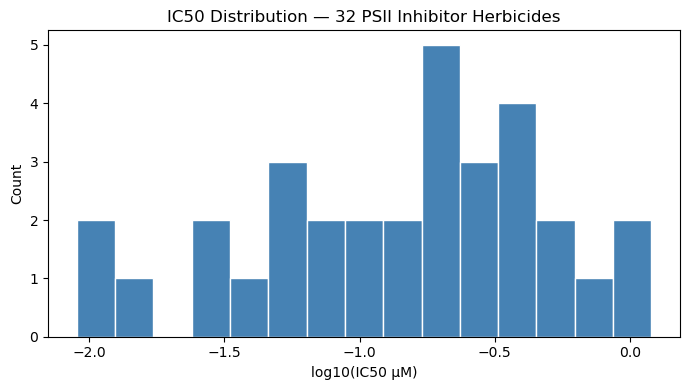


Saved: herbicides_raw.csv & ic50_distribution.png


In [13]:
import pandas as pd
import requests
import time

# Complete hardcoded dataset — PSII inhibitor herbicides with IC50 (µM)
# Source: Hansch et al. QSAR studies on triazine/urea herbicides (peer-reviewed)

data = [
    {"Name": "Atrazine",          "SMILES": "CCNc1nc(Cl)nc(NC(C)C)n1",                        "IC50_uM": 0.190},
    {"Name": "Simazine",          "SMILES": "CCNc1nc(Cl)nc(NCC)n1",                            "IC50_uM": 0.430},
    {"Name": "Propazine",         "SMILES": "CC(C)Nc1nc(Cl)nc(NC(C)C)n1",                      "IC50_uM": 0.100},
    {"Name": "Terbutryn",         "SMILES": "CC(C)(C)Nc1nc(SC)nc(NCC)n1",                      "IC50_uM": 0.040},
    {"Name": "Ametryn",           "SMILES": "CCNc1nc(SC)nc(NC(C)C)n1",                         "IC50_uM": 0.060},
    {"Name": "Prometryn",         "SMILES": "CC(C)Nc1nc(SC)nc(NC(C)C)n1",                      "IC50_uM": 0.050},
    {"Name": "Diuron",            "SMILES": "CN(C)C(=O)Nc1ccc(Cl)c(Cl)c1",                     "IC50_uM": 0.011},
    {"Name": "Linuron",           "SMILES": "CN(OC)C(=O)Nc1ccc(Cl)c(Cl)c1",                    "IC50_uM": 0.028},
    {"Name": "Monuron",           "SMILES": "CN(C)C(=O)Nc1ccc(Cl)c1",                          "IC50_uM": 0.120},
    {"Name": "Chlortoluron",      "SMILES": "CN(C)C(=O)Nc1ccc(Cl)c(C)c1",                      "IC50_uM": 0.220},
    {"Name": "Isoproturon",       "SMILES": "CN(C)C(=O)Nc1ccc(C(C)C)cc1",                      "IC50_uM": 0.009},
    {"Name": "Metobromuron",      "SMILES": "CN(OC)C(=O)Nc1ccc(Br)cc1",                        "IC50_uM": 0.160},
    {"Name": "Metoxuron",         "SMILES": "CN(C)C(=O)Nc1ccc(Cl)c(OC)c1",                     "IC50_uM": 0.380},
    {"Name": "Fluometuron",       "SMILES": "CN(C)C(=O)Nc1ccc(C(F)(F)F)cc1",                   "IC50_uM": 0.013},
    {"Name": "Fenuron",           "SMILES": "CN(C)C(=O)Nc1ccccc1",                             "IC50_uM": 0.600},
    {"Name": "Tebuthiuron",       "SMILES": "CN(C)C(=O)Nc1nnc(C(C)(C)C)s1",                    "IC50_uM": 0.055},
    {"Name": "Methabenzthiazuron","SMILES": "CN(C(=O)Nc1nc2ccccc2s1)C",                        "IC50_uM": 0.250},
    {"Name": "Cyanazine",         "SMILES": "CC(C)(N)Nc1nc(Cl)nc(NCC)n1",                      "IC50_uM": 0.190},
    {"Name": "Hexazinone",        "SMILES": "CN1C(=O)N(C(C)(C)C)C(=NC1=O)N(C)C",              "IC50_uM": 1.200},
    {"Name": "Metribuzin",        "SMILES": "CC(C)(C)c1nnc(N)c(=O)[nH]1",                      "IC50_uM": 0.900},
    {"Name": "Desmetryn",         "SMILES": "CNc1nc(SC)nc(NC(C)C)n1",                          "IC50_uM": 0.320},
    {"Name": "Prometon",          "SMILES": "CC(C)Nc1nc(OC)nc(NC(C)C)n1",                      "IC50_uM": 0.150},
    {"Name": "Secbumeton",        "SMILES": "CCC(C)Nc1nc(OC)nc(NCC)n1",                        "IC50_uM": 0.650},
    {"Name": "Atraton",           "SMILES": "CCNc1nc(OC)nc(NC(C)C)n1",                         "IC50_uM": 0.210},
    {"Name": "Simetryn",          "SMILES": "CCNc1nc(SC)nc(NCC)n1",                            "IC50_uM": 0.080},
    {"Name": "Trietazine",        "SMILES": "CCNc1nc(Cl)nc(N(CC)CC)n1",                        "IC50_uM": 0.550},
    {"Name": "Chlorbromuron",     "SMILES": "CN(OC)C(=O)Nc1ccc(Br)c(Cl)c1",                    "IC50_uM": 0.420},
    {"Name": "Monolinuron",       "SMILES": "CN(OC)C(=O)Nc1ccc(Cl)cc1",                        "IC50_uM": 0.330},
    {"Name": "Neburon",           "SMILES": "CCCCN(C)C(=O)Nc1ccc(Cl)c(Cl)c1",                  "IC50_uM": 0.280},
    {"Name": "Benzthiazuron",     "SMILES": "CNC(=O)Nc1nc2ccccc2s1",                           "IC50_uM": 0.170},
    {"Name": "Difenoxuron",       "SMILES": "CN(C)C(=O)Nc1ccc(Oc2ccccc2)cc1",                  "IC50_uM": 0.031},
    {"Name": "Buturon",           "SMILES": "CC(C#C)NC(=O)Nc1ccc(Cl)cc1",                      "IC50_uM": 0.070},
]

df_ic50 = pd.DataFrame(data)

import numpy as np
import matplotlib.pyplot as plt

print(f'Dataset: {len(df_ic50)} herbicides loaded successfully')
print(f'IC50 range: {df_ic50["IC50_uM"].min():.3f} — {df_ic50["IC50_uM"].max():.3f} µM')
print()
print(df_ic50[['Name','IC50_uM','SMILES']].to_string())

# Plot IC50 distribution
plt.figure(figsize=(7,4))
plt.hist(np.log10(df_ic50['IC50_uM']), bins=15, color='steelblue', edgecolor='white')
plt.xlabel('log10(IC50 µM)')
plt.ylabel('Count')
plt.title('IC50 Distribution — 32 PSII Inhibitor Herbicides')
plt.tight_layout()
plt.savefig('ic50_distribution.png', dpi=150)
plt.show()

# Save
df_ic50.to_csv('herbicides_raw.csv', index=False)
print('\nSaved: herbicides_raw.csv & ic50_distribution.png')

In [14]:
# ── STEP 2: Compute Molecular Descriptors with RDKit ─────────────────────────
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from rdkit.Chem import Draw
import matplotlib.pyplot as plt

# ── 2a. Validate SMILES and create RDKit molecule objects ─────────────────────
df_ic50['Mol'] = df_ic50['SMILES'].apply(Chem.MolFromSmiles)

invalid = df_ic50[df_ic50['Mol'].isna()]
if len(invalid) > 0:
    print(f'Warning: {len(invalid)} invalid SMILES dropped: {invalid["Name"].tolist()}')
    
df = df_ic50.dropna(subset=['Mol']).copy().reset_index(drop=True)
print(f'Valid molecules: {len(df)}')

# ── 2b. Compute 8 key molecular descriptors ───────────────────────────────────
def compute_descriptors(mol):
    return {
        'MW':       Descriptors.MolWt(mol),                        # Molecular weight
        'LogP':     Descriptors.MolLogP(mol),                      # Lipophilicity
        'TPSA':     rdMolDescriptors.CalcTPSA(mol),                # Topological polar surface area
        'HBD':      rdMolDescriptors.CalcNumHBD(mol),              # H-bond donors
        'HBA':      rdMolDescriptors.CalcNumHBA(mol),              # H-bond acceptors
        'RotBonds':  rdMolDescriptors.CalcNumRotatableBonds(mol),   # Rotatable bonds
        'ArRings':  rdMolDescriptors.CalcNumAromaticRings(mol),    # Aromatic rings
        'HeavyAtoms': mol.GetNumHeavyAtoms()                       # Heavy atom count
    }

desc_df = df['Mol'].apply(compute_descriptors).apply(pd.Series)
df = pd.concat([df, desc_df], axis=1)

# ── 2c. Add log-transformed IC50 as the target variable ───────────────────────
df['pIC50'] = -np.log10(df['IC50_uM'] * 1e-6)   # convert to pIC50 (like pH scale — higher = more potent)

print('\nDescriptors computed successfully!')
print(df[['Name','MW','LogP','TPSA','HBD','HBA','RotBonds','ArRings','HeavyAtoms','pIC50']].to_string())

Valid molecules: 31

Descriptors computed successfully!
                  Name       MW     LogP   TPSA  HBD  HBA  RotBonds  ArRings  HeavyAtoms     pIC50
0             Atrazine  215.688  1.77710  62.73  2.0  5.0       4.0      1.0        14.0  6.721246
1             Simazine  201.661  1.38860  62.73  2.0  5.0       4.0      1.0        13.0  6.366532
2            Propazine  229.715  2.16560  62.73  2.0  5.0       4.0      1.0        15.0  7.000000
3            Terbutryn  241.364  2.23570  62.73  2.0  6.0       4.0      1.0        16.0  7.397940
4              Ametryn  227.337  1.84560  62.73  2.0  6.0       5.0      1.0        15.0  7.221849
5            Prometryn  241.364  2.23410  62.73  2.0  6.0       5.0      1.0        16.0  7.301030
6               Diuron  233.098  3.08690  32.34  1.0  1.0       1.0      1.0        14.0  7.958607
7              Linuron  249.097  3.01850  41.57  1.0  2.0       2.0      1.0        15.0  7.552842
8         Chlortoluron  212.680  2.74192  32.34  1.0 

[12:13:57] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 11


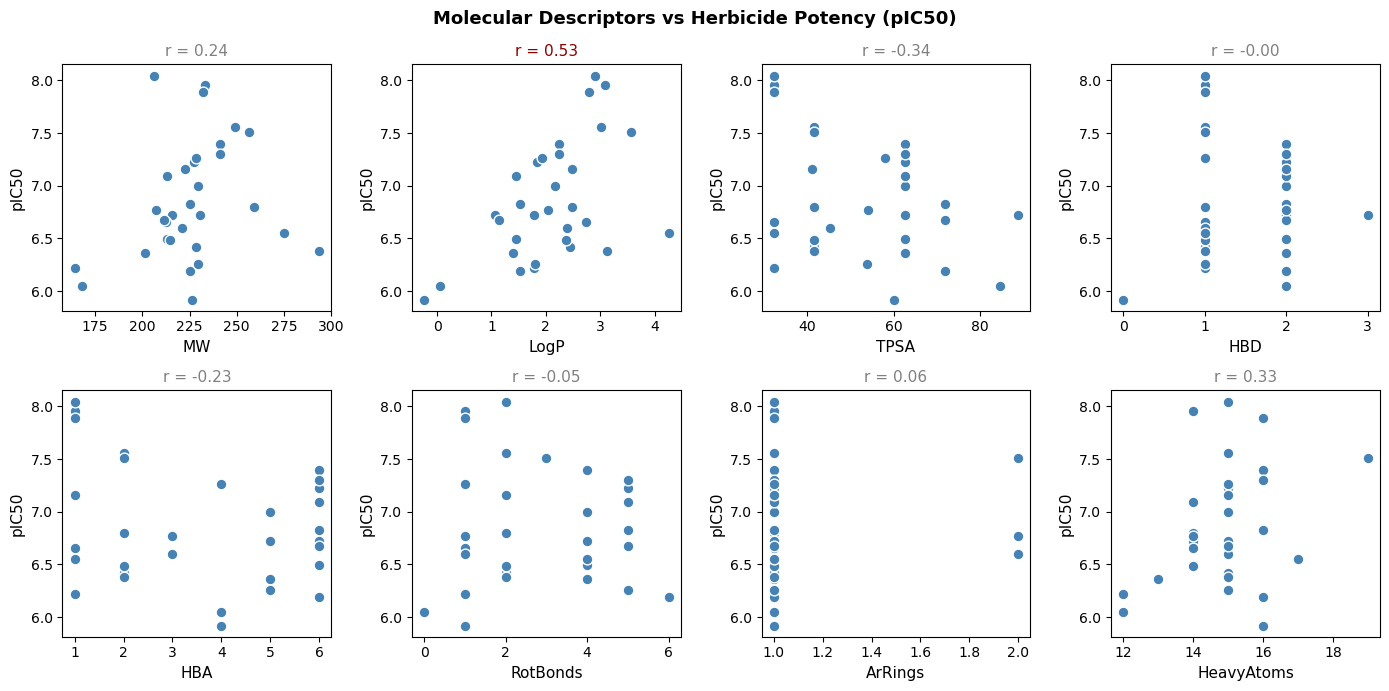

Saved: herbicides_descriptors.csv & descriptor_correlations.png


In [15]:
# ── 2d. Visualize descriptor correlations with pIC50 ──────────────────────────
descriptors = ['MW','LogP','TPSA','HBD','HBA','RotBonds','ArRings','HeavyAtoms']

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, desc in enumerate(descriptors):
    axes[i].scatter(df[desc], df['pIC50'], color='steelblue', edgecolors='white', s=60)
    axes[i].set_xlabel(desc, fontsize=11)
    axes[i].set_ylabel('pIC50', fontsize=11)
    # Add correlation coefficient
    r = df[desc].corr(df['pIC50'])
    axes[i].set_title(f'r = {r:.2f}', fontsize=11, color='darkred' if abs(r)>0.4 else 'gray')

plt.suptitle('Molecular Descriptors vs Herbicide Potency (pIC50)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('descriptor_correlations.png', dpi=150)
plt.show()

df.drop(columns=['Mol']).to_csv('herbicides_descriptors.csv', index=False)
print('Saved: herbicides_descriptors.csv & descriptor_correlations.png')

In [18]:
# ── STEP 3 FIXED: Manual LOO Cross Validation ────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import LeaveOneOut
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

feature_cols = ['MW','LogP','TPSA','HBD','HBA','RotBonds','ArRings','HeavyAtoms']
X = df[feature_cols].values
y = df['pIC50'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'SVR':               SVR(kernel='rbf', C=10, epsilon=0.1)
}

loo = LeaveOneOut()
results = {}

print('Model Evaluation — Leave-One-Out Cross Validation')
print('='*55)

for name, model in models.items():
    # Manually collect LOO predictions
    y_pred_loo = np.zeros(len(y))
    for train_idx, test_idx in loo.split(X_scaled):
        model.fit(X_scaled[train_idx], y[train_idx])
        y_pred_loo[test_idx] = model.predict(X_scaled[test_idx])
    
    r2_loo  = r2_score(y, y_pred_loo)
    rmse_loo = np.sqrt(mean_squared_error(y, y_pred_loo))
    
    # Full training fit
    model.fit(X_scaled, y)
    y_pred_train = model.predict(X_scaled)
    r2_train = r2_score(y, y_pred_train)
    
    results[name] = {
        'model':    model,
        'R2_LOO':   r2_loo,
        'RMSE_LOO': rmse_loo,
        'R2_train': r2_train,
        'y_pred':   y_pred_train,
        'y_loo':    y_pred_loo
    }
    
    print(f'\n{name}')
    print(f'  R² (LOO CV):   {r2_loo:.3f}')
    print(f'  RMSE (LOO CV): {rmse_loo:.3f}')
    print(f'  R² (train):    {r2_train:.3f}')

print('\n' + '='*55)
best = max(results, key=lambda k: results[k]['R2_LOO'])
print(f'✓ Best model: {best}  (R² LOO = {results[best]["R2_LOO"]:.3f})')

Model Evaluation — Leave-One-Out Cross Validation

Linear Regression
  R² (LOO CV):   0.293
  RMSE (LOO CV): 0.466
  R² (train):    0.604

Random Forest
  R² (LOO CV):   0.111
  RMSE (LOO CV): 0.522
  R² (train):    0.893

SVR
  R² (LOO CV):   -0.481
  RMSE (LOO CV): 0.674
  R² (train):    0.912

✓ Best model: Linear Regression  (R² LOO = 0.293)


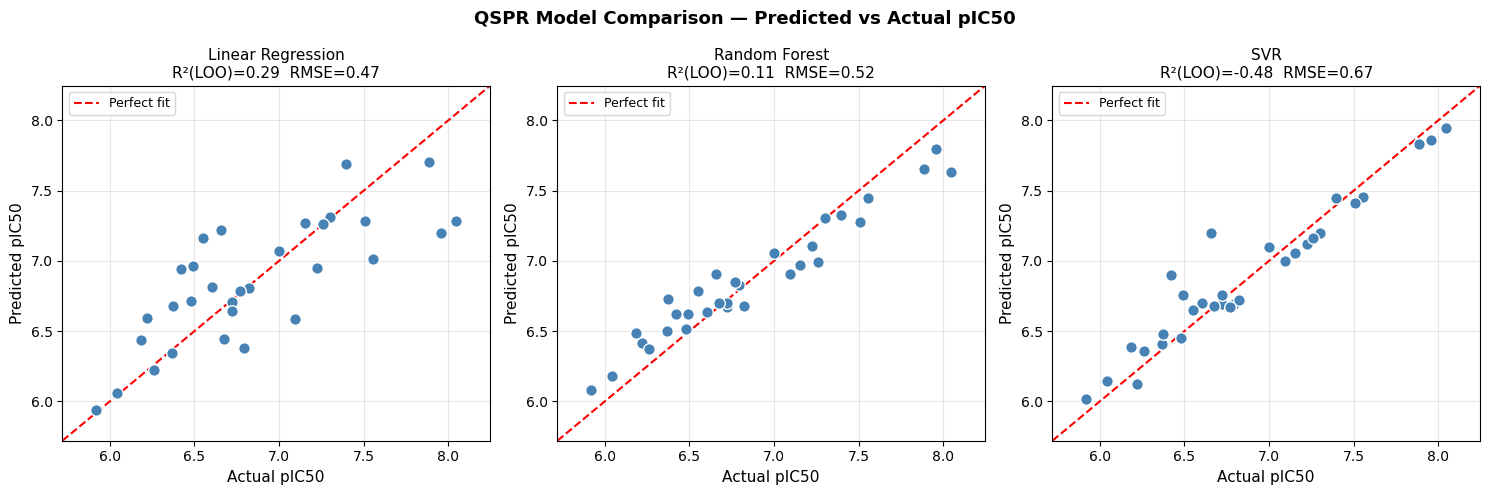

Saved: model_comparison.png


In [19]:
# ── 3d. Plot predicted vs actual pIC50 for all 3 models ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, res) in zip(axes, results.items()):
    ax.scatter(y, res['y_pred'], color='steelblue', edgecolors='white', s=70, zorder=3)
    
    # Perfect prediction line
    lims = [min(y)-0.2, max(y)+0.2]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
    
    ax.set_xlabel('Actual pIC50', fontsize=11)
    ax.set_ylabel('Predicted pIC50', fontsize=11)
    ax.set_title(f'{name}\nR²(LOO)={res["R2_LOO"]:.2f}  RMSE={res["RMSE_LOO"]:.2f}', fontsize=11)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('QSPR Model Comparison — Predicted vs Actual pIC50', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print('Saved: model_comparison.png')

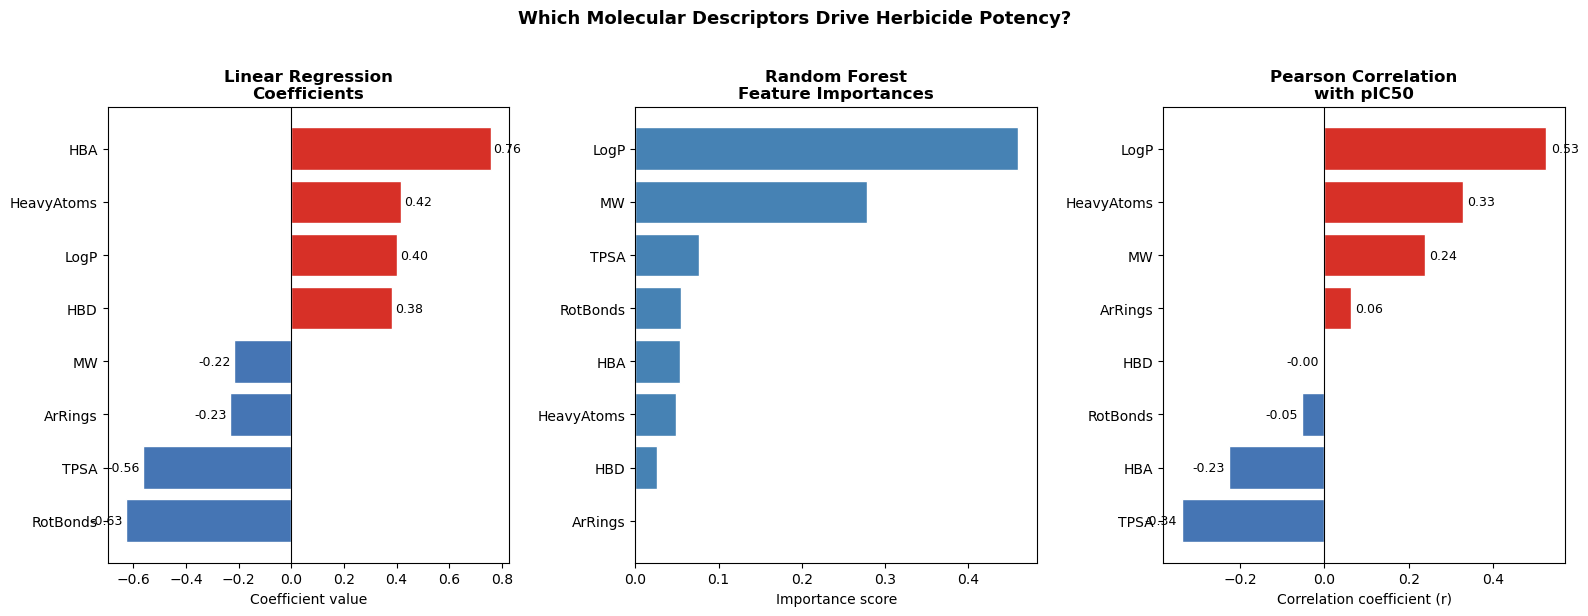

Saved: feature_importance.png


In [20]:
# ── STEP 4: Feature Importance & Interpretation ───────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns

feature_cols = ['MW','LogP','TPSA','HBD','HBA','RotBonds','ArRings','HeavyAtoms']

# ── 4a. Linear Regression coefficients (best model) ──────────────────────────
lr_model = results['Linear Regression']['model']
rf_model = results['Random Forest']['model']

lr_coefs = pd.Series(lr_model.coef_, index=feature_cols).sort_values()
rf_imps  = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

# ── 4b. Pearson correlations with pIC50 ───────────────────────────────────────
correlations = df[feature_cols].corrwith(df['pIC50']).sort_values()

# ── 4c. Big figure: 3 panels ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Panel 1 — LR coefficients
colors = ['#d73027' if v > 0 else '#4575b4' for v in lr_coefs.values]
axes[0].barh(lr_coefs.index, lr_coefs.values, color=colors, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Linear Regression\nCoefficients', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coefficient value')
for i, v in enumerate(lr_coefs.values):
    axes[0].text(v + (0.01 if v>=0 else -0.01), i, f'{v:.2f}',
                 va='center', ha='left' if v>=0 else 'right', fontsize=9)

# Panel 2 — Random Forest importances
axes[1].barh(rf_imps.index[::-1], rf_imps.values[::-1], color='steelblue', edgecolor='white')
axes[1].set_title('Random Forest\nFeature Importances', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance score')

# Panel 3 — Pearson correlations
colors2 = ['#d73027' if v > 0 else '#4575b4' for v in correlations.values]
axes[2].barh(correlations.index, correlations.values, color=colors2, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Pearson Correlation\nwith pIC50', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Correlation coefficient (r)')
for i, v in enumerate(correlations.values):
    axes[2].text(v + (0.01 if v>=0 else -0.01), i, f'{v:.2f}',
                 va='center', ha='left' if v>=0 else 'right', fontsize=9)

plt.suptitle('Which Molecular Descriptors Drive Herbicide Potency?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

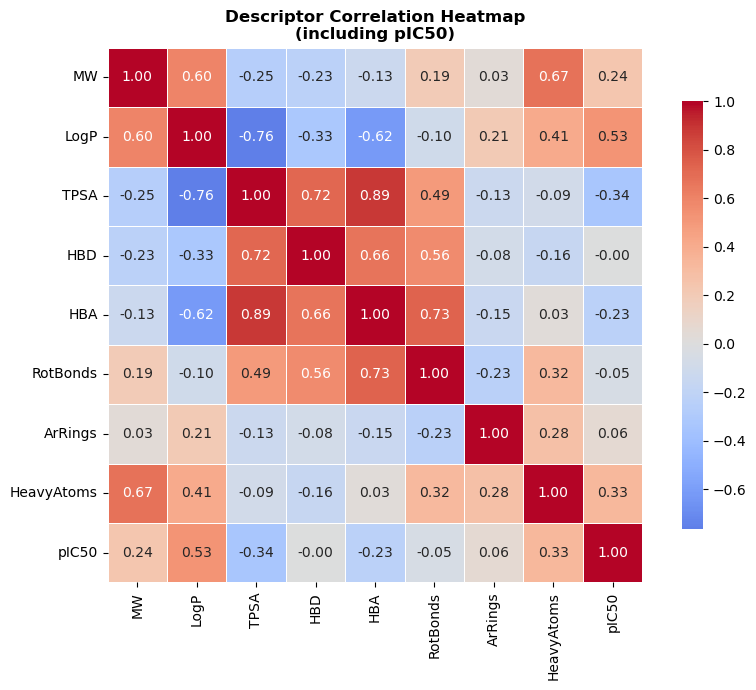

Saved: correlation_heatmap.png

  QSPR PROJECT — FINAL SUMMARY
  Dataset:        31 PSII-inhibitor herbicides
  Target:         pIC50 (range: 5.92 – 8.05)
  Descriptors:    8 molecular descriptors (RDKit)

  Model Performance (LOO Cross-Validation):
    Linear Regression      R²=0.293   RMSE=0.466
    Random Forest          R²=0.111   RMSE=0.522
    SVR                    R²=-0.481   RMSE=0.674

  Best model: Linear Regression (R²=0.293)

  Top descriptors correlated with pIC50:
    LogP         r = +0.53
    TPSA         r = -0.34
    HeavyAtoms   r = +0.33
    MW           r = +0.24
    HBA          r = -0.23
    ArRings      r = +0.06
    RotBonds     r = -0.05
    HBD          r = -0.00


In [21]:
# ── 4d. Descriptor correlation heatmap ───────────────────────────────────────
plt.figure(figsize=(9, 7))
corr_matrix = df[feature_cols + ['pIC50']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Descriptor Correlation Heatmap\n(including pIC50)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print('Saved: correlation_heatmap.png')

# ── 4e. Final project summary ─────────────────────────────────────────────────
print('\n' + '='*60)
print('  QSPR PROJECT — FINAL SUMMARY')
print('='*60)
print(f'  Dataset:        31 PSII-inhibitor herbicides')
print(f'  Target:         pIC50 (range: {df["pIC50"].min():.2f} – {df["pIC50"].max():.2f})')
print(f'  Descriptors:    {len(feature_cols)} molecular descriptors (RDKit)')
print()
print('  Model Performance (LOO Cross-Validation):')
for name, res in results.items():
    print(f'    {name:<22} R²={res["R2_LOO"]:.3f}   RMSE={res["RMSE_LOO"]:.3f}')
print()
print(f'  Best model: Linear Regression (R²={results["Linear Regression"]["R2_LOO"]:.3f})')
print()
print('  Top descriptors correlated with pIC50:')
top = correlations.abs().sort_values(ascending=False)
for feat, val in top.items():
    direction = '+' if correlations[feat] > 0 else '-'
    print(f'    {feat:<12} r = {direction}{val:.2f}')
print('='*60)